# Imports

In [83]:
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# EDA and preprocessing

In [77]:
data = pd.read_csv("train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Check null values

In [78]:
for col in data.columns:
    print(col, data[col].isna().sum())

print()
print(data["Cabin"].isna().sum() / data.shape[0])
print(data["Age"].isna().sum() / data.shape[0])
print(data["Embarked"].isna().sum() / data.shape[0])

PassengerId 0
Survived 0
Pclass 0
Name 0
Sex 0
Age 177
SibSp 0
Parch 0
Ticket 0
Fare 0
Cabin 687
Embarked 2

0.7710437710437711
0.19865319865319866
0.002244668911335578


- 77% passengers without a cabin
- PassengerId doesn't affect result
- Ticket is a random string
- Name is just a name

Therefore, drop these columns

In [79]:
clean_data = data.drop(columns=["PassengerId", "Cabin", "Ticket", "Name"])

In [80]:
clean_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [88]:
def plot_counts(data, features, target="Survived", cols=2):
    n = len(features)
    rows = math.ceil(n / cols)

    _, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for idx, feature in enumerate(features):
        df = data.groupby([feature, target])[target].count().reset_index(name="count")
        sns.barplot(data=df, x=feature, y="count", hue=target, ax=axes[idx])
        axes[idx].set_title(f"{feature} → {target}")
        axes[idx].tick_params(axis="x", rotation=30)

    # скрываем пустые ячейки, если фич меньше чем слотов
    for j in range(len(features), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

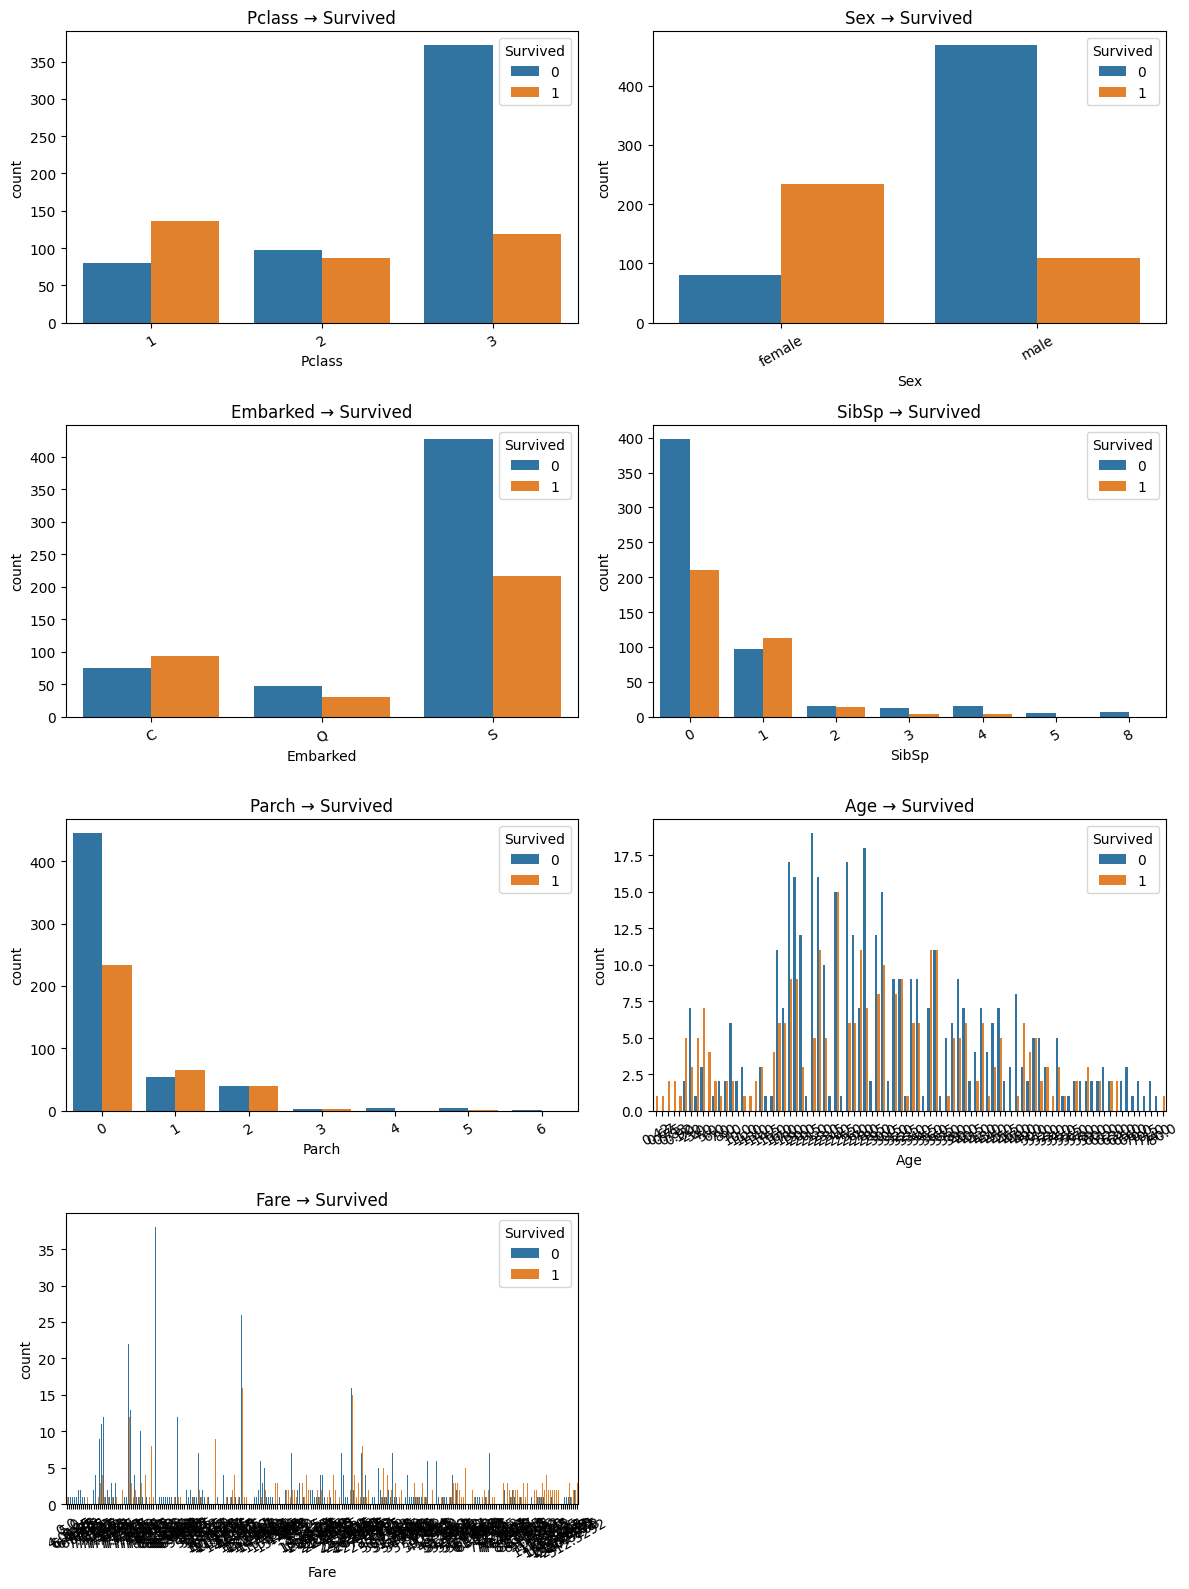

In [89]:
features = ["Pclass", "Sex", "Embarked", "SibSp", "Parch", "Age", "Fare"]

plot_counts(data, features)

- 3 class sucks
- women...
- embarked, parch, sibsp need more research
- age and fares have too many different fares => need to treat them as intervals

Age and fare are continuous features => convert them into ordinal